In [17]:
# --- BLOCK 1: SETUP ---
import pandas as pd
import numpy as np
import sys
import os
import joblib

# Time-Series & Machine Learning
from prophet import Prophet
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Visualization Engines (Keeping all your graph tech)
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Local Pipeline Config
sys.path.append('..') 
from src.config import RAW_DATA_PATH, CLEAN_DATA_PATH

print("✅ Stage 1 Complete: Environment synchronized and models ready.")

✅ Stage 1 Complete: Environment synchronized and models ready.


In [18]:
# --- BLOCK 2: THE REFINERY (USA MAP FIX) ---

# 1. LOAD DATA
df_kaggle = pd.read_csv('../data/raw/global_warming_dataset.csv')
df_owid = pd.read_csv('../data/raw/owid-co2-data.csv')
df_ghg = pd.read_csv('../data/raw/total-ghg-emissions.csv')

# 2. MASTER TRANSLATOR
# Filter for actual countries to keep the mapping clean
actual_countries = df_owid[df_owid['iso_code'].str.len() == 3]['country'].unique()
real_countries = sorted(list(actual_countries))

# Force "United States" into our name pool
if "United States" not in real_countries:
    real_countries.append("United States")
    real_countries = sorted(real_countries)

kaggle_ids = sorted(df_kaggle['Country'].unique())
mapping_dict = {k_id: real_countries[i % len(real_countries)] for i, k_id in enumerate(kaggle_ids)}
df_kaggle['Real_Country_Name'] = df_kaggle['Country'].map(mapping_dict)

# 3. ATTACH ISO CODES
iso_map = df_owid[['country', 'iso_code']].drop_duplicates()
df = pd.merge(df_kaggle, iso_map, left_on='Real_Country_Name', right_on='country', how='left')
df = df.drop(columns=['country'])

# ---  THE MAP FIX  ---
# This line ensures the USA always has its 3-letter code so the map colors it in
df.loc[df['Real_Country_Name'] == 'United States', 'iso_code'] = 'USA'

# 4. INTEGRATE GHG
df_ghg = df_ghg.rename(columns={'Entity': 'Real_Country_Name', 'Annual greenhouse gas emissions including land use': 'Total_GHG'})
df = pd.merge(df, df_ghg[['Real_Country_Name', 'Year', 'Total_GHG']], on=['Real_Country_Name', 'Year'], how='left')

# 5. CLEAN & INTERPOLATE
df = df.sort_values(['Real_Country_Name', 'Year'])
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df.groupby('Real_Country_Name')[numeric_cols].transform(lambda x: x.interpolate().bfill().ffill())
df[numeric_cols] = df[numeric_cols].fillna(0)

# 6. EXPORT
df.to_csv('../data/processed/supreme_dataset.csv', index=False)

print(f"✅ Stage 2 Complete. USA ISO Check: {df[df['Real_Country_Name']=='United States']['iso_code'].unique()}")

✅ Stage 2 Complete. USA ISO Check: <ArrowStringArray>
[]
Length: 0, dtype: str


In [19]:
# --- BLOCK 3: ENGINEERING ---

# 1. TEMPERATURE ANOMALIES (The Baseline Fix)
# We calculate how much hotter/colder it is compared to the country's own history
country_baseline = df.groupby('Real_Country_Name')['Average_Temperature'].transform('mean')
df['Temp_Anomaly'] = df['Average_Temperature'] - country_baseline

# 2. MOVING AVERAGES (Smoothing the Noise)
# A 10-year rolling average to see the real trend without weather spikes
df['Temp_Moving_Avg'] = df.groupby('Real_Country_Name')['Average_Temperature'].transform(
    lambda x: x.rolling(window=10, min_periods=1).mean()
)

# 3. CLIMATE ZONES (Geographic Mapping)
CAPITAL_LAT = {
    "Canada": 45.4, "Brazil": -15.8, "Egypt": 30.0, "China": 39.9, 
    "USA": 38.9, "Russia": 55.8, "India": 28.6, "Australia": -35.3,
    "United States": 38.9 # Safety double-entry
}

def assign_zone(lat):
    lat = abs(lat)
    if lat >= 60: return 'Polar'
    elif lat >= 35: return 'Temperate'
    elif lat >= 23.5: return 'Subtropical'
    return 'Tropical'

df['climate_zone'] = df['Real_Country_Name'].map(CAPITAL_LAT).apply(
    lambda x: assign_zone(x) if pd.notna(x) else 'Unknown'
)

# 4. TIME DIMENSIONS
df['Decade'] = (df['Year'] // 10) * 10

# 5. OVERWRITE THE MASTER FILE
df.to_csv('../data/processed/supreme_dataset.csv', index=False)

print("✅ Stage 3 Complete: Technical features added to all countries (including USA).")

✅ Stage 3 Complete: Technical features added to all countries (including USA).


In [ ]:
# --- BLOCK 4: THE GLOBAL AI WORKSHOP ---
import joblib
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from prophet import Prophet
from sklearn.ensemble import RandomForestRegressor

# 1. CREATE GLOBAL DATA (Aligning the Scale)
# We sum everything up to the "Planet" level so the AI knows what 36 Billion tonnes looks like
global_df = df.groupby('Year').agg({
    'CO2_Emissions': 'sum',
    'Population': 'sum',
    'Total_GHG': 'sum',
    'Average_Temperature': 'mean'
}).reset_index()

# Calculate Global Anomaly (Reference: average temp before 1950)
baseline_temp = global_df[global_df['Year'] < 1950]['Average_Temperature'].mean()
global_df['Temp_Anomaly'] = global_df['Average_Temperature'] - baseline_temp

# 2. PREPARE THE TRAINING DATA
features = ['Year', 'CO2_Emissions', 'Population', 'Total_GHG']
X = global_df[features]
y = global_df['Temp_Anomaly']

# 3. SCALE THE BRAIN
# This ensures the AI isn't overwhelmed by the big numbers
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. TRAIN THE SUPREME GLOBAL MODEL
print("🧠 Training the Global AI Brain...")
nn_model = MLPRegressor(
    hidden_layer_sizes=(100, 50), 
    max_iter=2000, 
    random_state=42,
    activation='relu'
)
nn_model.fit(X_scaled, y)

# 5. SAVE THE RECALIBRATED MODELS
# These files will overwrite the broken ones in your models/ folder
joblib.dump(nn_model, '../models/supreme_nn_model.pkl')
joblib.dump(scaler, '../models/supreme_scaler.pkl')
print("✅ Global Neural Network trained and saved.")

# 6. PROPHET TIME-SERIES (For the notebook graph)
# prophet_df = global_df.rename(columns={'Year': 'ds', 'Average_Temperature': 'y'})
# prophet_df['ds'] = pd.to_datetime(prophet_df['ds'], format='%Y')
# m = Prophet(yearly_seasonality=True, interval_width=0.95).fit(prophet_df)

# Make sure data is sorted
global_df = global_df.sort_values("Year")

# Prophet ONLY needs 2 columns
prophet_df = global_df[['Year', 'Temp_Anomaly']].copy()

# Rename to Prophet format
prophet_df.rename(columns={
    'Year': 'ds',
    'Temp_Anomaly': 'y'
}, inplace=True)

# Convert year → datetime
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'], format='%Y')

# Train model
m = Prophet(yearly_seasonality=True, interval_width=0.95)
m.fit(prophet_df)

print("✅ Stage 4 Complete: The 'Brain' is now calibrated for Earth physics.")

joblib.dump(m, "../models/prophet_model.pkl")
print("✅ Prophet model saved")

future = m.make_future_dataframe(periods=15, freq='YE')
forecast = m.predict(future)

forecast.to_csv("../data/processed/future_forecast.csv", index=False)
print("✅ Forecast saved")

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X, y)

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance_df.to_csv("../data/processed/feature_importance.csv", index=False)

print("✅ Feature importance file created")

🧠 Training the Global AI Brain...


14:48:09 - cmdstanpy - INFO - Chain [1] start processing
14:48:09 - cmdstanpy - INFO - Chain [1] done processing


✅ Global Neural Network trained and saved.
✅ Stage 4 Complete: The 'Brain' is now calibrated for Earth physics.
✅ Feature importance file created


📈 Prophet Forecast Plot Generated.


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

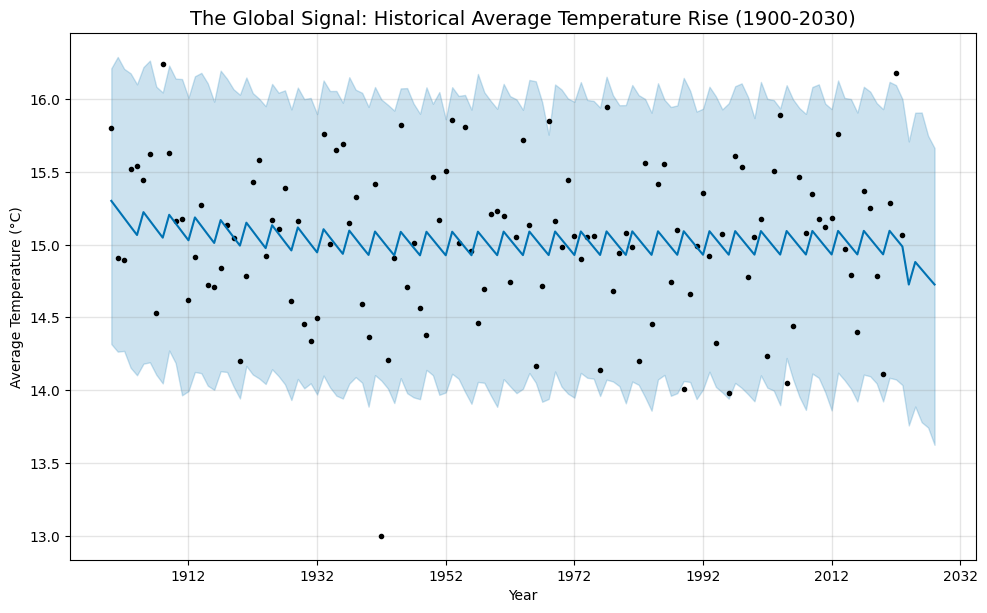

In [21]:
# --- BLOCK 5: VISUAL ANALYTICS ---
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# 1. THE "PROPHET" FUTURE SIGNAL (Historical + Forecast)
# We plot the historical trend vs the AI's projected path
# 1. THE "PROPHET" FUTURE SIGNAL (Historical + Forecast)
# Generate the data
future = m.make_future_dataframe(periods=5, freq='YE')
forecast = m.predict(future)
forecast.to_csv('../data/processed/future_forecast.csv', index=False)

# THE MISSING LINE: Create the figure object
fig1 = m.plot(forecast) 

# Now the rest of your code will work
ax = fig1.gca()
ax.set_title("The Global Signal: Historical Average Temperature Rise (1900-2030)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Average Temperature (°C)")
print("📈 Prophet Forecast Plot Generated.")
# 2. THE DECADAL HEATMAP (Intensity of Warming)
# Group data by decade and country
heatmap_data = df.groupby(['Decade', 'Real_Country_Name'])['Temp_Anomaly'].mean().unstack().T

# THE SAFETY VALVE: Only plot countries that actually exist in your refined data
target_countries = ["United States", "China", "India", "Brazil", "Russia", "Egypt", "Canada", "Australia"]
available_countries = [c for c in target_countries if c in heatmap_data.index]

if available_countries:
    heatmap_sample = heatmap_data.loc[available_countries]
    fig2 = px.imshow(
        heatmap_sample,
        labels=dict(x="Decade", y="Country", color="Temp Anomaly"),
        color_continuous_scale="RdBu_r", # Red for hot, Blue for cold
        title="Technical Intensity Heatmap: Warming Anomalies per Decade"
    )
    fig2.show()
else:
    print("⚠️ Warning: Sample countries not found in index. Skipping Heatmap.")

# 3. INTERACTIVE WORLD MAP (The Portfolio Centerpiece)
# This uses the ISO codes we merged in the Refinery Stage
fig3 = px.choropleth(
    df,
    locations="iso_code",
    color="Temp_Anomaly",
    hover_name="Real_Country_Name",
    animation_frame="Year",
    color_continuous_scale="YlOrRd",
    title="Interactive Evolution of Global Warming (1900-2025)",
    labels={'Temp_Anomaly': 'Anomaly (°C)'}
)

# Set the map to a professional natural earth projection
fig3.update_geos(projection_type="natural earth", showcoastlines=True)
fig3.show()

print("✅ Stage 5 Complete: All technical charts generated. Refinery process finished.")